In [3]:
import pandas as pd
import numpy as np

pci_df = pd.read_csv('properties_census_isd_tract_numeric.csv')

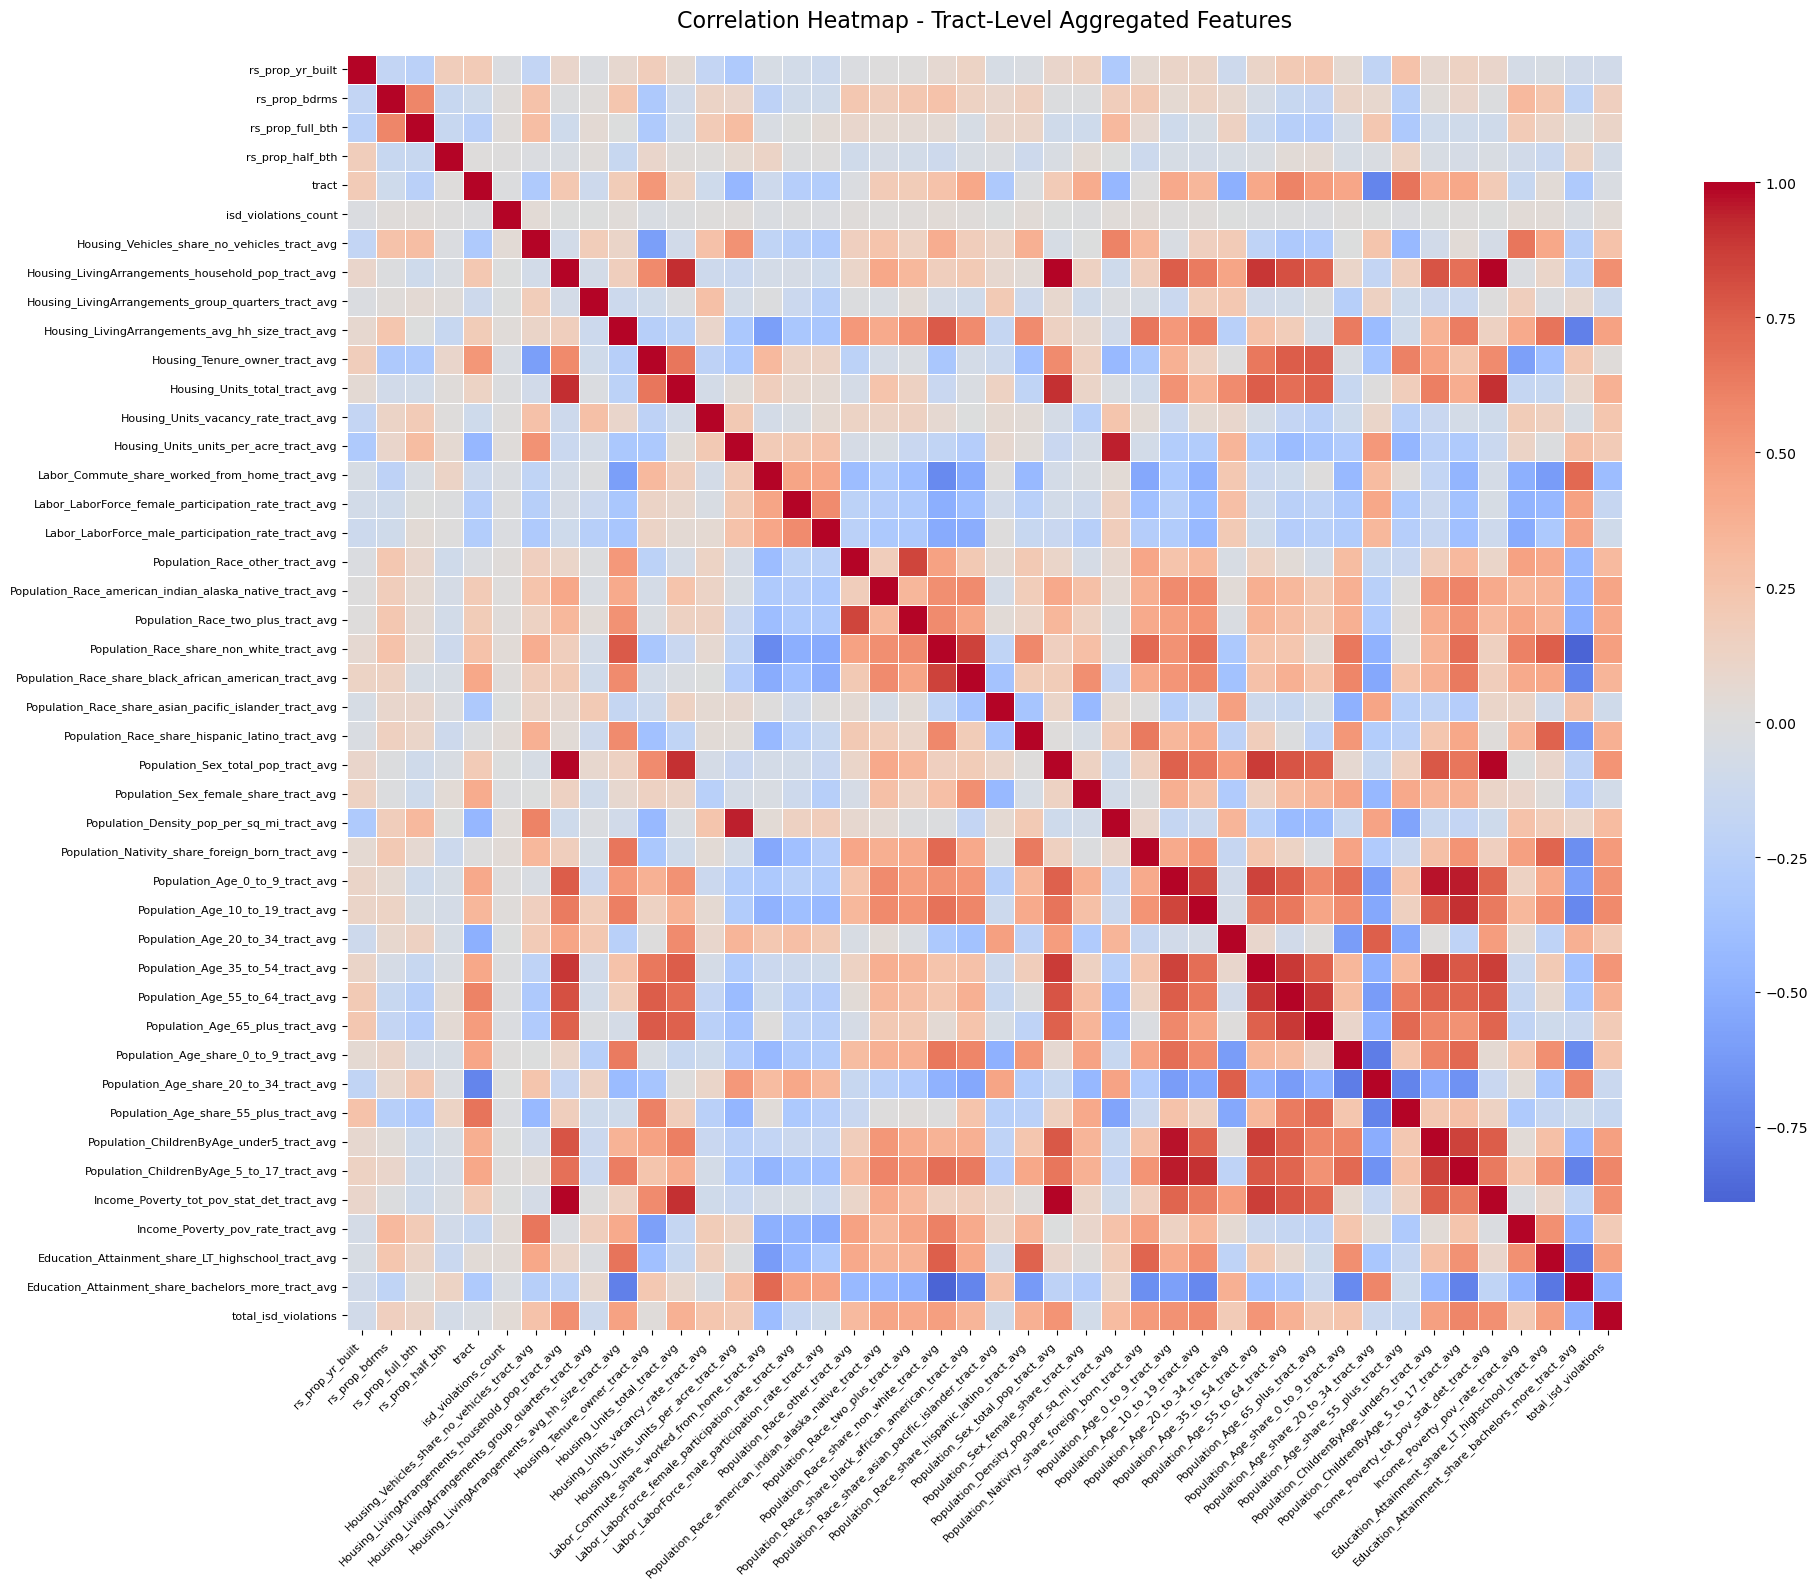

In [4]:
#correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Remove property-level demographic columns in favor of their tract avg counterparts
demographic_cols_to_drop = [
    'Housing_Vehicles_share_no_vehicles',
    'Housing_LivingArrangements_household_pop',
    'Housing_LivingArrangements_group_quarters',
    'Housing_LivingArrangements_avg_hh_size',
    'Housing_Units_total',
    'Housing_Units_vacancy_rate',
    'Housing_Units_units_per_acre',
    'Labor_Commute_share_worked_from_home',
    'Labor_LaborForce_female_participation_rate',
    'Labor_LaborForce_male_participation_rate',
    'Population_Race_other',
    'Population_Race_american_indian_alaska_native',
    'Population_Race_two_plus',
    'Population_Race_share_non_white',
    'Population_Race_share_black_african_american',
    'Population_Race_share_asian_pacific_islander',
    'Population_Race_share_hispanic_latino',
    'Population_Sex_total_pop',
    'Population_Sex_female_share',
    'Population_Density_pop_per_sq_mi',
    'Population_Nativity_share_foreign_born',
    'Population_Age_0_to_9',
    'Population_Age_10_to_19',
    'Population_Age_20_to_34',
    'Population_Age_35_to_54',
    'Population_Age_55_to_64',
    'Population_Age_65_plus',
    'Population_Age_share_0_to_9',
    'Population_Age_share_20_to_34',
    'Population_Age_share_55_plus',
    'Population_ChildrenByAge_under5',
    'Population_ChildrenByAge_5_to_17',
    'Income_Poverty_tot_pov_stat_det',
    'Income_Poverty_pov_rate',
    'Education_Attainment_share_LT_highschool',
    'Education_Attainment_share_bachelors_more'
]

# Drop the demographic columns and save to pci2_df
pci2_df = pci_df.drop(columns=demographic_cols_to_drop, errors='ignore')

# Calculate correlation matrix
correlation_matrix = pci2_df.corr()

plt.figure(figsize=(20, 16))

# Create heatmap 
sns.heatmap(correlation_matrix, 
            annot=False,  # Remove numbers to avoid clutter
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap - Tract-Level Aggregated Features', 
          fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

In [5]:
#linear regression pci2df
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Prepare data
X = pci2_df.drop(columns=['total_isd_violations'])
y = pci2_df['total_isd_violations']

In [6]:
#split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# fit model
model = LinearRegression()
model.fit(X_train, y_train)
# predict
y_pred = model.predict(X_test)



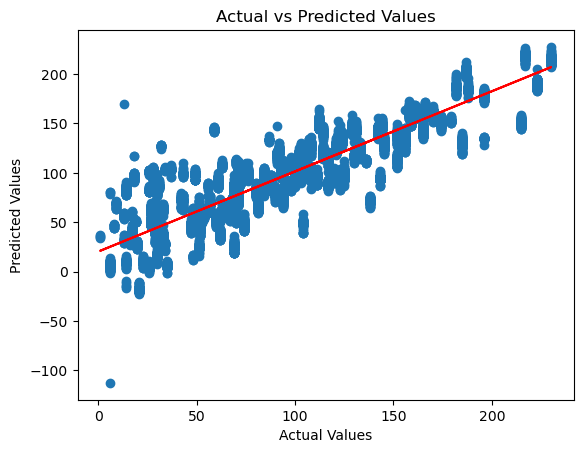

In [7]:
#plot 
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
# trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red')

plt.show()

In [8]:
#eval using r squared, mae, and rmse
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from math import sqrt

mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2 Score: {r2}")


Mean Absolute Error: 16.913384236861212
Root Mean Squared Error: 23.071995436209782
R^2 Score: 0.8091211306524424


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X)
Xscaled = scaler.transform(X)
X_scaled_train, X_scaled_test, y_scaled_train, y_scaled_test = train_test_split(Xscaled, y, test_size=0.2, random_state=42)
# fit model
scaled_model = LinearRegression()
scaled_model.fit(X_scaled_train, y_scaled_train)
# predict
y_scaled_pred = scaled_model.predict(X_scaled_test)

scaled_mae = mean_absolute_error(y_scaled_test, y_scaled_pred)
scaled_rmse = sqrt(mean_squared_error(y_scaled_test, y_scaled_pred))
scaled_r2 = r2_score(y_scaled_test, y_scaled_pred)
print(f"Mean Absolute Error: {scaled_mae}")
print(f"Root Mean Squared Error: {scaled_rmse}")
print(f"R^2 Score: {scaled_r2}")

Mean Absolute Error: 16.91338579698897
Root Mean Squared Error: 23.07199556081459
R^2 Score: 0.8091211285906853


In [37]:

for feature in range(len(X.columns)):
    print(X.columns[feature], ": ", scaled_model.coef_[feature])

# for i in range(-1, len(X.columns)):
#     if i == -1:
#         print()

rs_prop_yr_built :  -21.25475495998104
rs_prop_bdrms :  4.98532550666366
rs_prop_full_bth :  22.018721888550044
rs_prop_half_bth :  1.322852938464338
tract :  -44.2721573450907
isd_violations_count :  28.557287154307883
Housing_Vehicles_share_no_vehicles_tract_avg :  28.151702408891733
Housing_LivingArrangements_household_pop_tract_avg :  1038281815.0954545
Housing_LivingArrangements_group_quarters_tract_avg :  709499020.1316972
Housing_LivingArrangements_avg_hh_size_tract_avg :  -95.27428813829333
Housing_Tenure_owner_tract_avg :  51.90501493288472
Housing_Units_total_tract_avg :  -280.1673978026528
Housing_Units_vacancy_rate_tract_avg :  154.968663754428
Housing_Units_units_per_acre_tract_avg :  69.2187953500657
Labor_Commute_share_worked_from_home_tract_avg :  -44.57104843835716
Labor_LaborForce_female_participation_rate_tract_avg :  -20.623667675926498
Labor_LaborForce_male_participation_rate_tract_avg :  6.203711063979385
Population_Race_other_tract_avg :  -0.05042321909185986
Pop

In [ ]:
# just for making the map stuff

tract_isd_counts = pci2_df[["tract", "total_isd_violations"]]
tract_isd_counts.drop_duplicates().to_csv("tract_violation_count.csv")
# tract_isd_counts.shape
# pci2_df.shape
